<a href="https://colab.research.google.com/github/RohithMaggekavalKrishna/Oil-Price-Direction-Prediction-using-ML/blob/main/FeedforwardNNOilPriceModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feedforward Neural Network — WTI Crude Oil Price Direction Forecasting

This notebook implements a **Feedforward Neural Network (FFNN)** for binary classification of next-day WTI Crude Oil price direction (Up / Down).

**Pipeline overview:**
1. Load raw FRED-MD and WTI daily price data from Google Drive.
2. Select the 31 required macro variables and apply t-code stationarity transformations.
3. Apply a 1-month reporting lag and forward-fill macro values to daily rows.
4. Construct 30 lagged price features and the binary direction target.
5. Split chronologically into train / validation / test — no shuffling.
6. Run 5-fold `TimeSeriesSplit` cross-validation, fitting a fresh `StandardScaler` inside each fold.
7. Train the final FFNN and evaluate fully out-of-sample on the test set.
8. Report all required metrics: Accuracy, Precision, Recall (per class), Confusion Matrix, F1, ROC-AUC.

The `FFNNPriceDirectionModel` class inherits from `BaseForecastModel` as required.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Imports

All libraries needed for data handling, deep learning (TensorFlow/Keras), scikit-learn metrics, and visualisation.

In [ ]:
# =============================================================================
# 0. IMPORTS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from abc import ABC, abstractmethod
from typing import List, Dict, Optional

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Base Abstract Class

The `BaseForecastModel` abstract class is provided by the professor and defines the interface every model must implement: `fit`, `predict`, `evaluate`, `save`, and `load`.

In [ ]:
# =============================================================================
# 1. BASE ABSTRACT CLASS (provided by professor)
# =============================================================================

class BaseForecastModel(ABC):
    """
    Abstract base class that all forecasting models must inherit from.
    Enforces a consistent interface: fit, predict, evaluate, save, load.
    """

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train): pass

    @abstractmethod
    def predict(self, X): pass

    @abstractmethod
    def evaluate(self, X_test, y_test): pass

    @abstractmethod
    def save(self, filepath: str): pass

    @abstractmethod
    def load(self, filepath: str): pass

## 2. Load Raw Data

We load:
- **FRED-MD** monthly macroeconomic dataset.
- **WTI Crude Oil Futures** daily price history.

Both DataFrames are cleaned, date-parsed, and sorted chronologically.

In [ ]:
# =============================================================================
# 2. LOAD RAW DATA
# =============================================================================

print("=" * 60)
print("STEP 2: Loading Data")
print("=" * 60)

fred_df = pd.read_csv('/content/drive/MyDrive/VIP/FRED-MD_2024m12.csv')
oil_df  = pd.read_csv('/content/drive/MyDrive/VIP/Crude Oil WTI Futures Historical Data (1).csv')

# --- Clean oil data: keep only Date and Price ---
oil_df.columns = oil_df.columns.str.strip()
oil_df['Date']  = pd.to_datetime(oil_df['Date'], format='%m/%d/%Y')
oil_df['Price'] = pd.to_numeric(oil_df['Price'].astype(str).str.replace(',', ''), errors='coerce')
oil_df = oil_df[['Date', 'Price']].dropna().sort_values('Date').reset_index(drop=True)

# --- Clean FRED-MD data: drop the transform-code header row ---
fred_df = fred_df[fred_df['sasdate'] != 'Transform:'].reset_index(drop=True)
fred_df['sasdate'] = pd.to_datetime(fred_df['sasdate'], format='%m/%d/%Y')
for col in fred_df.columns[1:]:
    fred_df[col] = pd.to_numeric(fred_df[col], errors='coerce')
fred_df = fred_df.sort_values('sasdate').reset_index(drop=True)

print(f"  Oil data  : {oil_df.shape}  |  {oil_df['Date'].min().date()} → {oil_df['Date'].max().date()}")
print(f"  FRED data : {fred_df.shape}  |  {fred_df['sasdate'].min().date()} → {fred_df['sasdate'].max().date()}")

STEP 2: Loading Data
  Oil data  : (5000, 2)  |  1999-01-04 → 2018-09-07
  FRED data : (791, 127)  |  1959-01-01 → 2024-11-01


## 3. Select Macro Features and Apply T-Code Transformations

We use exactly the **31 variables** specified in the assignment.  
Each FRED-MD variable is transformed to stationarity using its official **t-code**:

| T-Code | Transformation |
|--------|----------------|
| 1 | Level (no change) |
| 2 | First difference: $x_t - x_{t-1}$ |
| 5 | Log first difference: $\ln(x_t) - \ln(x_{t-1})$ |
| 6 | Log second difference: $(\ln x_t - \ln x_{t-1}) - (\ln x_{t-1} - \ln x_{t-2})$ |

T-codes sourced from the official FRED-MD appendix.

In [ ]:
# =============================================================================
# 3. SELECT MACRO FEATURES & APPLY T-CODE TRANSFORMATIONS
# =============================================================================

print("\n" + "=" * 60)
print("STEP 3: T-Code Stationarity Transformations")
print("=" * 60)

# Official t-codes for all 31 required variables
# Source: https://files.stlouisfed.org/files/htdocs/fred-databases/FRED-QD_appendix_v6.pdf
TCODE_MAP = {
    'RPI'         : 5,  # log first difference
    'W875RX1'     : 5,
    'CMRMTSPLx'   : 5,
    'IPFPNSS'     : 5,
    'USWTRADE'    : 5,
    'USTRADE'     : 5,
    'BUSLOANS'    : 5,
    'CONSPI'      : 5,
    'S&P 500'     : 5,
    'S&P PE ratio': 5,
    'FEDFUNDS'    : 2,  # first difference
    'TB3MS'       : 2,
    'TB6MS'       : 2,
    'GS1'         : 2,
    'GS5'         : 2,
    'GS10'        : 2,
    'AAA'         : 2,
    'BAA'         : 2,
    'TB3SMFFM'    : 1,  # level (spread — already stationary)
    'TB6SMFFM'    : 1,
    'T1YFFM'      : 1,
    'T5YFFM'      : 1,
    'T10YFFM'     : 1,
    'AAAFFM'      : 1,
    'BAAFFM'      : 1,
    'EXSZUSx'     : 5,  # log first difference
    'EXJPUSx'     : 5,
    'EXUSUKx'     : 5,
    'EXCAUSx'     : 5,
    'PPICMM'      : 6,  # log second difference
    'UMCSENTx'    : 2,  # first difference
}

MACRO_FEATURES = list(TCODE_MAP.keys())

def apply_tcode(series: pd.Series, tcode: int) -> pd.Series:
    """Apply the FRED-MD stationarity transformation for the given tcode."""
    if tcode == 1:
        return series
    elif tcode == 2:
        return series.diff()
    elif tcode == 3:
        return series.diff().diff()
    elif tcode == 4:
        return np.log(series.clip(lower=1e-10))
    elif tcode == 5:
        return np.log(series.clip(lower=1e-10)).diff()
    elif tcode == 6:
        log_s = np.log(series.clip(lower=1e-10))
        return log_s.diff().diff()
    else:
        raise ValueError(f"Unknown tcode: {tcode}")

# Build a transformed FRED DataFrame
fred_transformed = fred_df[['sasdate']].copy()
for feat in MACRO_FEATURES:
    fred_transformed[feat] = apply_tcode(fred_df[feat], TCODE_MAP[feat])

print(f"  Applied t-code transformations to {len(MACRO_FEATURES)} macro variables.")
print(f"  Transformation counts: "
      f"level={sum(v==1 for v in TCODE_MAP.values())}, "
      f"1st-diff={sum(v==2 for v in TCODE_MAP.values())}, "
      f"log-1st-diff={sum(v==5 for v in TCODE_MAP.values())}, "
      f"log-2nd-diff={sum(v==6 for v in TCODE_MAP.values())}")


STEP 3: T-Code Stationarity Transformations
  Applied t-code transformations to 31 macro variables.
  Transformation counts: level=7, 1st-diff=9, log-1st-diff=14, log-2nd-diff=1


## 4. Apply 1-Month Reporting Lag and Forward-Fill to Daily Data

FRED-MD is released with a **1-month reporting delay**:
- January macro values become available only from February onward.
- We shift the macro `sasdate` forward by 1 month, then use `merge_asof` to **forward-fill** across trading days.

Result: every trading day in month M is assigned macro values from month M−1 — zero future leakage.

In [ ]:
# =============================================================================
# 4. APPLY 1-MONTH LAG + FORWARD-FILL ALIGNMENT TO DAILY PRICES
# =============================================================================

print("\n" + "=" * 60)
print("STEP 4: 1-Month Lag & Forward-Fill Alignment")
print("=" * 60)

# Shift sasdate forward by 1 month: Jan values become available in Feb
fred_lagged = fred_transformed.copy()
fred_lagged['sasdate'] = fred_lagged['sasdate'] + pd.DateOffset(months=1)

# Build a daily date scaffold spanning the full oil price range
daily_dates = pd.DataFrame({'Date': pd.date_range(
    start=oil_df['Date'].min(), end=oil_df['Date'].max(), freq='D'
)})

# Forward-fill: each calendar day gets the most recent available monthly macro value
fred_lagged_sorted = fred_lagged.sort_values('sasdate').rename(columns={'sasdate': 'Date'})
daily_macro = pd.merge_asof(
    daily_dates.sort_values('Date'),
    fred_lagged_sorted,
    on='Date',
    direction='backward'   # take the last macro observation on or before each date
)

# Merge aligned macro onto oil price data (inner join keeps only trading days)
merged_df = pd.merge(oil_df, daily_macro, on='Date', how='inner')
merged_df = merged_df.sort_values('Date').reset_index(drop=True)

print(f"  Forward-fill complete. Merged shape: {merged_df.shape}")
print(f"  Date range: {merged_df['Date'].min().date()} → {merged_df['Date'].max().date()}")
print("  Each trading day carries the previous month's macro values.")


STEP 4: 1-Month Lag & Forward-Fill Alignment
  Forward-fill complete. Merged shape: (5000, 33)
  Date range: 1999-01-04 → 2018-09-07
  Each trading day carries the previous month's macro values.


## 5. Feature Engineering: Lagged Prices and Binary Target

**Input features:**  
30 lagged daily closing prices `Oil_Lag1` … `Oil_Lag30`.  
At row $t$, `Oil_Lagk` = $\text{Price}_{t-k}$, so no future price is ever included.

**Target variable:**  
Binary label: **1** if $\text{Price}_{t+1} > \text{Price}_t$ (Up), **0** otherwise (Down/flat).  
Constructed with `Price.shift(-1) > Price`, then rows with NaN lags or target are dropped.

At prediction time $t$, all features come from $t-1$ and earlier — no look-ahead bias.

In [ ]:
# =============================================================================
# 5. FEATURE ENGINEERING: 30 LAGGED PRICES + BINARY TARGET
# =============================================================================

print("\n" + "=" * 60)
print("STEP 5: Feature Engineering & Target Construction")
print("=" * 60)

LOOKBACK = 30

# Lagged closing prices: Oil_Lag1 = yesterday's price, ..., Oil_Lag30 = 30 days ago
for lag in range(1, LOOKBACK + 1):
    merged_df[f'Oil_Lag{lag}'] = merged_df['Price'].shift(lag)

# Binary target: 1 if next-day price > today's price
merged_df['Target'] = (merged_df['Price'].shift(-1) > merged_df['Price']).astype(int)

# Drop rows where any lag or the target is NaN
before = len(merged_df)
merged_df = merged_df.dropna().reset_index(drop=True)
after = len(merged_df)

print(f"  Created {LOOKBACK} lagged price features.")
print(f"  Dropped {before - after} NaN rows → {after} rows remaining.")
print(f"  Date range after cleaning: {merged_df['Date'].min().date()} → {merged_df['Date'].max().date()}")
print(f"  Target: Up={merged_df['Target'].sum()} ({merged_df['Target'].mean()*100:.1f}%), "
      f"Down={len(merged_df)-merged_df['Target'].sum()} ({(1-merged_df['Target'].mean())*100:.1f}%)")


STEP 5: Feature Engineering & Target Construction
  Created 30 lagged price features.
  Dropped 30 NaN rows → 4970 rows remaining.
  Date range after cleaning: 1999-02-17 → 2018-09-07
  Target: Up=2583 (52.0%), Down=2387 (48.0%)


## 6. Define Features and Target Arrays

**X:** 30 lagged price features + 31 stationary macro features = **61 features**.  
**y:** Binary direction label (0 or 1).

Extra oil market columns (Open, High, Low, Vol., Change%) are excluded to stay within the specified feature set.

In [ ]:
# =============================================================================
# 6. DEFINE FEATURE AND TARGET ARRAYS
# =============================================================================

print("\n" + "=" * 60)
print("STEP 6: Feature and Target Definition")
print("=" * 60)

LAG_FEATURES = [f'Oil_Lag{i}' for i in range(1, LOOKBACK + 1)]   # 30 features
ALL_FEATURES = LAG_FEATURES + MACRO_FEATURES                       # 30 + 31 = 61

X     = merged_df[ALL_FEATURES].values
y     = merged_df['Target'].values
dates = merged_df['Date'].values

print(f"  Lagged price features : {len(LAG_FEATURES)}")
print(f"  Macro features        : {len(MACRO_FEATURES)}")
print(f"  Total features (X)    : {X.shape[1]}")
print(f"  Total samples         : {X.shape[0]}")
print(f"  Target: 0 = Down, 1 = Up")


STEP 6: Feature and Target Definition
  Lagged price features : 30
  Macro features        : 31
  Total features (X)    : 61
  Total samples         : 4970
  Target: 0 = Down, 1 = Up


## 7. Time-Based Train / Validation / Test Split

Strictly chronological split — **no shuffling**:
- **Train**: up to end of 2014
- **Validation**: 2015–2017
- **Test**: 2018 onward

Financial time series must always be split this way to preserve temporal order.

In [ ]:
# =============================================================================
# 7. TIME-BASED TRAIN / VALIDATION / TEST SPLIT (no shuffling)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 7: Train / Validation / Test Split")
print("=" * 60)

TRAIN_END = '2014-12-31'
VAL_END   = '2017-12-31'

dates_series = pd.Series(dates)
train_mask   = dates_series <= TRAIN_END
val_mask     = (dates_series > TRAIN_END) & (dates_series <= VAL_END)
test_mask    = dates_series > VAL_END

X_train, y_train = X[train_mask.values], y[train_mask.values]
X_val,   y_val   = X[val_mask.values],   y[val_mask.values]
X_test,  y_test  = X[test_mask.values],  y[test_mask.values]

print(f"  Training   : {X_train.shape[0]} rows  (up to {TRAIN_END})")
print(f"  Validation : {X_val.shape[0]} rows  ({TRAIN_END[:4]}–{VAL_END[:4]})")
print(f"  Test       : {X_test.shape[0]} rows  (after {VAL_END})")
print("  ✓ No shuffling — strictly chronological split.")


STEP 7: Train / Validation / Test Split
  Training   : 3996 rows  (up to 2014-12-31)
  Validation : 791 rows  (2014–2017)
  Test       : 183 rows  (after 2017-12-31)
  ✓ No shuffling — strictly chronological split.


## 8. Normalization

`StandardScaler` is fit **only on training data**, then applied to validation and test sets.  
Fitting on the full dataset before splitting would leak future statistics into training — this is explicitly avoided.

In [ ]:
# =============================================================================
# 8. NORMALIZATION — fit on training data ONLY
# =============================================================================

print("\n" + "=" * 60)
print("STEP 8: Normalization")
print("=" * 60)

scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)   # fit + transform on train
X_val_sc   = scaler_X.transform(X_val)          # transform only
X_test_sc  = scaler_X.transform(X_test)         # transform only

print("  StandardScaler fitted on training data ONLY — no leakage.")
print(f"  X_train_sc shape : {X_train_sc.shape}")
print(f"  X_val_sc shape   : {X_val_sc.shape}")
print(f"  X_test_sc shape  : {X_test_sc.shape}")


STEP 8: Normalization
  StandardScaler fitted on training data ONLY — no leakage.
  X_train_sc shape : (3996, 61)
  X_val_sc shape   : (791, 61)
  X_test_sc shape  : (183, 61)


## 9. Helper: Compute Classification Metrics

A utility function that computes and prints all required metrics:
Accuracy, Precision/Recall per class, F1-score (macro), ROC-AUC, and the full classification report.

In [ ]:
# =============================================================================
# 9. HELPER: COMPUTE CLASSIFICATION METRICS
# =============================================================================

def compute_classification_metrics(y_true, y_pred_proba, label='', threshold=0.5):
    """
    Compute and print binary classification metrics.

    Returns a dict: accuracy, precision_0, recall_0, precision_1,
                    recall_1, f1_macro, roc_auc, y_pred.
    """
    y_pred = (y_pred_proba >= threshold).astype(int)

    metrics = {
        'accuracy'   : float(accuracy_score(y_true, y_pred)),
        'precision_0': float(precision_score(y_true, y_pred, pos_label=0, zero_division=0)),
        'recall_0'   : float(recall_score(y_true, y_pred, pos_label=0, zero_division=0)),
        'precision_1': float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'recall_1'   : float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'f1_macro'   : float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'roc_auc'    : float(roc_auc_score(y_true, y_pred_proba)),
        'y_pred'     : y_pred
    }

    if label:
        print(f"\n  {'='*50}")
        print(f"  {label}")
        print(f"  {'='*50}")
        print(f"  Accuracy            : {metrics['accuracy']:.4f}")
        print(f"  Precision (Down=0)  : {metrics['precision_0']:.4f}")
        print(f"  Recall    (Down=0)  : {metrics['recall_0']:.4f}")
        print(f"  Precision (Up=1)    : {metrics['precision_1']:.4f}")
        print(f"  Recall    (Up=1)    : {metrics['recall_1']:.4f}")
        print(f"  F1 (macro)          : {metrics['f1_macro']:.4f}")
        print(f"  ROC-AUC             : {metrics['roc_auc']:.4f}")
        print(f"\n  Classification Report:")
        print(classification_report(y_true, y_pred, target_names=['Down (0)', 'Up (1)']))

    return metrics

## 10. Baseline Model — Majority Class Predictor

The baseline always predicts the most frequent class in the training set. This gives a performance lower bound that the FFNN must surpass to demonstrate it has learned meaningful patterns.

In [ ]:
# =============================================================================
# 10. BASELINE MODEL — Majority Class Predictor
# =============================================================================

print("\n" + "=" * 60)
print("STEP 10: Baseline Model (Majority Class)")
print("=" * 60)

majority_class = int(np.bincount(y_train).argmax())
print(f"  Majority class in training set: {'Up (1)' if majority_class == 1 else 'Down (0)'}")

baseline_test_pred = np.full(len(y_test), majority_class)
print(f"  Baseline Test Accuracy : {accuracy_score(y_test, baseline_test_pred):.4f}")


STEP 10: Baseline Model (Majority Class)
  Majority class in training set: Up (1)
  Baseline Test Accuracy : 0.5902


## 11. FFNN Model Class

The `FFNNPriceDirectionModel` class inherits from `BaseForecastModel` and implements all required abstract methods.

**Architecture:**
- Dense(128, ReLU) → BatchNorm → Dropout(0.3)
- Dense(64, ReLU, L2) → Dropout(0.2)
- Dense(32, ReLU, L2) → Dropout(0.2)
- Dense(1, Sigmoid) ← binary output

**Training setup:**
- Loss: Binary cross-entropy | Optimiser: Adam (lr=0.001)
- Early stopping (patience=20) on `val_loss`, restoring best weights.
- ReduceLROnPlateau (factor=0.5, patience=10) to fine-tune learning rate.
- Hyperparameters selected based on cross-validation performance in Step 12.

In [ ]:
# =============================================================================
# 11. FFNN MODEL CLASS (inherits from BaseForecastModel)
# =============================================================================

class FFNNPriceDirectionModel(BaseForecastModel):
    """
    Feedforward Neural Network for binary classification of
    next-day oil price direction (Up=1, Down=0).

    Inherits from BaseForecastModel and implements all abstract methods:
    fit, predict, evaluate, save, load.

    Architecture:
        Dense(128, relu) → BatchNorm → Dropout
        Dense(64,  relu, L2) → Dropout
        Dense(32,  relu, L2) → Dropout
        Dense(1, sigmoid)  ← binary output
    """

    def __init__(
        self,
        hidden_units: List[int] = [128, 64, 32],
        dropout_rates: List[float] = [0.3, 0.2, 0.2],
        learning_rate: float = 0.001,
        l2_lambda: float = 0.001,
        task_type: str = 'classification'
    ):
        # Call parent constructor with task_type and all hyperparameters
        super().__init__(
            task_type=task_type,
            hidden_units=hidden_units,
            dropout_rates=dropout_rates,
            learning_rate=learning_rate,
            l2_lambda=l2_lambda
        )
        self.hidden_units   = hidden_units
        self.dropout_rates  = dropout_rates
        self.learning_rate  = learning_rate
        self.l2_lambda      = l2_lambda
        self.model          = None
        self.history        = None
        self.n_features     = None

    def build_model(self, n_features: int):
        """
        Build the FFNN architecture for binary classification.
        Input shape: (n_features,).
        """
        self.n_features = n_features
        model = Sequential(name='FFNN_Price_Direction')
        model.add(Input(shape=(n_features,)))

        for i, (units, drop) in enumerate(zip(self.hidden_units, self.dropout_rates)):
            # First layer: include BatchNormalization for stable training
            if i == 0:
                model.add(Dense(units, activation='relu'))
                model.add(BatchNormalization())
            else:
                model.add(Dense(units, activation='relu',
                                kernel_regularizer=l2(self.l2_lambda)))
            model.add(Dropout(drop))

        # Output: single sigmoid neuron for P(Up)
        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        self.model = model
        return model

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: Optional[np.ndarray] = None,
        y_val: Optional[np.ndarray] = None,
        epochs: int = 200,
        batch_size: int = 32,
        patience: int = 20,
        verbose: int = 1
    ):
        """
        Train the FFNN with early stopping and learning rate scheduling.

        Args:
            X_train / y_train : training data and binary labels
            X_val   / y_val   : validation data for early stopping
            epochs            : maximum training epochs
            batch_size        : mini-batch size
            patience          : early stopping patience (epochs without improvement)
        """
        if self.model is None:
            self.build_model(X_train.shape[1])

        monitor = 'val_loss' if X_val is not None else 'loss'
        callbacks = [
            EarlyStopping(monitor=monitor, patience=patience,
                          restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor=monitor, factor=0.5,
                              patience=10, min_lr=1e-6, verbose=0)
        ]

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val) if X_val is not None else None,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=verbose
        )
        return self.history

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Return predicted probabilities for the 'Up' class.
        Input shape: (samples, n_features).
        """
        if self.model is None:
            raise ValueError("Model not trained. Call fit() first.")
        return self.model.predict(X, verbose=0).flatten()

    def predict_classes(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """Convert sigmoid probabilities to binary class labels."""
        return (self.predict(X) >= threshold).astype(int)

    def evaluate(self, X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:
        """
        Evaluate the model on test data.

        Returns a dictionary with:
        accuracy, precision_0, recall_0, precision_1, recall_1, f1_macro, roc_auc.
        """
        proba  = self.predict(X_test)
        y_pred = (proba >= 0.5).astype(int)
        return {
            'accuracy'   : float(accuracy_score(y_test, y_pred)),
            'precision_0': float(precision_score(y_test, y_pred, pos_label=0, zero_division=0)),
            'recall_0'   : float(recall_score(y_test, y_pred, pos_label=0, zero_division=0)),
            'precision_1': float(precision_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'recall_1'   : float(recall_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'f1_macro'   : float(f1_score(y_test, y_pred, average='macro', zero_division=0)),
            'roc_auc'    : float(roc_auc_score(y_test, proba))
        }

    def save(self, filepath: str):
        """Save the Keras model and hyperparameters to disk."""
        os.makedirs(os.path.dirname(filepath) if os.path.dirname(filepath) else '.', exist_ok=True)
        self.model.save(f"{filepath}.keras")
        params = {
            'hidden_units' : self.hidden_units,
            'dropout_rates': self.dropout_rates,
            'learning_rate': self.learning_rate,
            'l2_lambda'    : self.l2_lambda,
            'n_features'   : self.n_features
        }
        with open(f"{filepath}_params.pkl", 'wb') as f:
            pickle.dump(params, f)
        print(f"  Model saved to {filepath}.keras")

    def load(self, filepath: str):
        """Load a previously saved Keras model and hyperparameters."""
        self.model = load_model(f"{filepath}.keras")
        with open(f"{filepath}_params.pkl", 'rb') as f:
            params = pickle.load(f)
        for k, v in params.items():
            setattr(self, k, v)
        print(f"  Model loaded from {filepath}.keras")

    def summary(self):
        """Print Keras model architecture summary."""
        if self.model:
            self.model.summary()

## 12. 5-Fold Time-Series Cross-Validation

We use `TimeSeriesSplit(n_splits=5)` which creates expanding training windows preserving chronological order.

**Critically, inside each fold:**
1. A fresh `StandardScaler` is fit **only on that fold's training portion**.
2. The validation portion is transformed with that fold's scaler.

This eliminates any intra-fold scaling leakage and is required by the assignment.

In [ ]:
# =============================================================================
# 12. 5-FOLD TIME-SERIES CROSS-VALIDATION
# =============================================================================

print("\n" + "=" * 60)
print("STEP 12: 5-Fold Expanding Window Cross-Validation")
print("=" * 60)

tscv       = TimeSeriesSplit(n_splits=5)
cv_results = []

for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
    print(f"\n  Fold {fold+1}/5  (train={len(tr_idx)}, val={len(vl_idx)})")

    # Fit scaler on this fold's TRAINING data only
    fold_scaler = StandardScaler()
    X_tr_sc = fold_scaler.fit_transform(X_train[tr_idx])
    X_vl_sc = fold_scaler.transform(X_train[vl_idx])

    y_tr = y_train[tr_idx]
    y_vl = y_train[vl_idx]

    # Train a fresh FFNN for this fold
    model_cv = FFNNPriceDirectionModel(
        hidden_units=[128, 64, 32],
        dropout_rates=[0.3, 0.2, 0.2],
        learning_rate=0.001,
        l2_lambda=0.001
    )
    model_cv.fit(X_tr_sc, y_tr, X_val=X_vl_sc, y_val=y_vl,
                 epochs=200, batch_size=32, patience=20, verbose=0)

    # Evaluate this fold
    fold_proba = model_cv.predict(X_vl_sc)
    fold_pred  = (fold_proba >= 0.5).astype(int)
    fold_acc   = accuracy_score(y_vl, fold_pred)
    fold_f1    = f1_score(y_vl, fold_pred, average='macro', zero_division=0)
    fold_auc   = roc_auc_score(y_vl, fold_proba)

    cv_results.append({'accuracy': fold_acc, 'f1_macro': fold_f1, 'roc_auc': fold_auc})
    print(f"    Accuracy : {fold_acc:.4f}")
    print(f"    F1 Macro : {fold_f1:.4f}")
    print(f"    ROC-AUC  : {fold_auc:.4f}")

print("\n  Cross-Validation Summary:")
for metric in ['accuracy', 'f1_macro', 'roc_auc']:
    values = [r[metric] for r in cv_results]
    print(f"    {metric:>10}: Mean={np.mean(values):.4f}  Std={np.std(values):.4f}")


STEP 12: 5-Fold Expanding Window Cross-Validation

  Fold 1/5  (train=666, val=666)
    Accuracy : 0.4880
    F1 Macro : 0.4536
    ROC-AUC  : 0.5239

  Fold 2/5  (train=1332, val=666)
    Accuracy : 0.4925
    F1 Macro : 0.4614
    ROC-AUC  : 0.5111

  Fold 3/5  (train=1998, val=666)
    Accuracy : 0.5090
    F1 Macro : 0.5071
    ROC-AUC  : 0.4996

  Fold 4/5  (train=2664, val=666)
    Accuracy : 0.5300
    F1 Macro : 0.5243
    ROC-AUC  : 0.5396

  Fold 5/5  (train=3330, val=666)
    Accuracy : 0.4640
    F1 Macro : 0.4091
    ROC-AUC  : 0.4791

  Cross-Validation Summary:
      accuracy: Mean=0.4967  Std=0.0220
      f1_macro: Mean=0.4711  Std=0.0409
       roc_auc: Mean=0.5106  Std=0.0206


## 13. Train Final Model

The final FFNN is trained on the **full training set** (scaled with the train-only scaler from Step 8), using the validation set for early stopping.  
Hyperparameters are identical to those used in cross-validation.

In [ ]:
# =============================================================================
# 13. TRAIN FINAL MODEL ON FULL TRAINING SET
# =============================================================================

print("\n" + "=" * 60)
print("STEP 13: Training Final Model")
print("=" * 60)

model = FFNNPriceDirectionModel(
    hidden_units=[128, 64, 32],
    dropout_rates=[0.3, 0.2, 0.2],
    learning_rate=0.001,
    l2_lambda=0.001
)

model.build_model(X_train_sc.shape[1])
model.summary()

model.fit(
    X_train_sc, y_train,
    X_val=X_val_sc, y_val=y_val,
    epochs=300,
    batch_size=32,
    patience=30,
    verbose=1
)


STEP 13: Training Final Model


Model: "FFNN_Price_Direction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,817 (73.50 KB)

 Trainable params: 18,561 (72.50 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5055 - loss: 0.8830 - val_accuracy: 0.5284 - val_loss: 0.8135 - learning_rate: 0.0010
Epoch 2/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5045 - loss: 0.8304 - val_accuracy: 0.4968 - val_loss: 0.8082 - learning_rate: 0.0010
Epoch 3/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5058 - loss: 0.8150 - val_accuracy: 0.5057 - val_loss: 0.8003 - learning_rate: 0.0010
Epoch 4/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5008 - loss: 0.8039 - val_accuracy: 0.5107 - val_loss: 0.7934 - learning_rate: 0.0010
Epoch 5/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5223 - loss: 0.7933 - val_accuracy: 0.5057 - val_loss: 0.7852 - learning_rate: 0.0010
Epoch 6/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5258 - loss: 0.7818 - val_accuracy: 0.5183 - val_loss: 0.7796 - learning_rate: 0.0010
Epoch 7/300
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5198 - loss: 0.

## 14. Evaluation — Out-of-Sample Metrics

All predictions are made on data the model **has never seen during training**.  
We report for both validation and test sets:
- Accuracy
- Precision and Recall for each class (Down=0, Up=1)
- F1-score (macro)
- ROC-AUC
- Full classification report
- Confusion matrix heatmaps


STEP 14: Out-of-Sample Evaluation

  Validation Set Metrics
  Accuracy            : 0.5019
  Precision (Down=0)  : 0.4468
  Recall    (Down=0)  : 0.0540
  Precision (Up=1)    : 0.5054
  Recall    (Up=1)    : 0.9353
  F1 (macro)          : 0.3763
  ROC-AUC             : 0.4943

  Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.45      0.05      0.10       389
      Up (1)       0.51      0.94      0.66       402

    accuracy                           0.50       791
   macro avg       0.48      0.49      0.38       791
weighted avg       0.48      0.50      0.38       791


  Test Set Metrics
  Accuracy            : 0.5738
  Precision (Down=0)  : 0.4776
  Recall    (Down=0)  : 0.4267
  Precision (Up=1)    : 0.6293
  Recall    (Up=1)    : 0.6759
  F1 (macro)          : 0.5512
  ROC-AUC             : 0.5677

  Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.48      0.43      0.45        

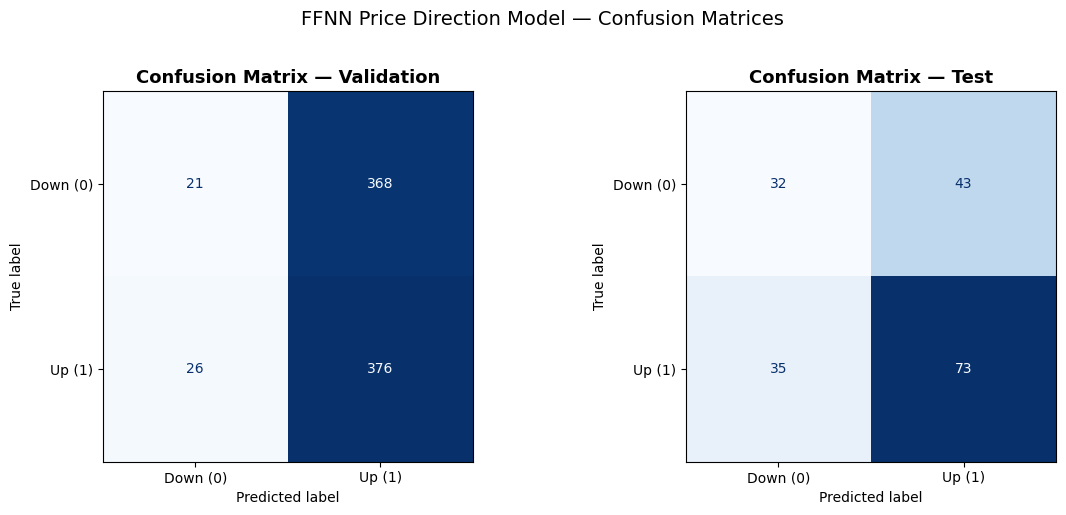

  Confusion matrices saved.


In [ ]:
# =============================================================================
# 14. EVALUATION — OUT-OF-SAMPLE METRICS
# =============================================================================

print("\n" + "=" * 60)
print("STEP 14: Out-of-Sample Evaluation")
print("=" * 60)

# Predicted probabilities (strictly out-of-sample)
val_proba  = model.predict(X_val_sc)
test_proba = model.predict(X_test_sc)

# Compute all classification metrics
val_metrics  = compute_classification_metrics(y_val,  val_proba,  'Validation Set Metrics')
test_metrics = compute_classification_metrics(y_test, test_proba, 'Test Set Metrics')

# --- Confusion matrix heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_val,  val_metrics['y_pred'],  'Confusion Matrix — Validation'),
    (axes[1], y_test, test_metrics['y_pred'], 'Confusion Matrix — Test')
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down (0)', 'Up (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('FFNN Price Direction Model — Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ffnn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Confusion matrices saved.")

## 15. Visualisations

Four plots to assess model behaviour:
1. **Training & Validation Loss** — checks for overfitting.
2. **Training & Validation Accuracy** — convergence view.
3. **Predicted Probability Distribution** — shows how confident the model is on each class.
4. **Rolling 30-Day Accuracy on Test Set** — checks for consistency across different market regimes.

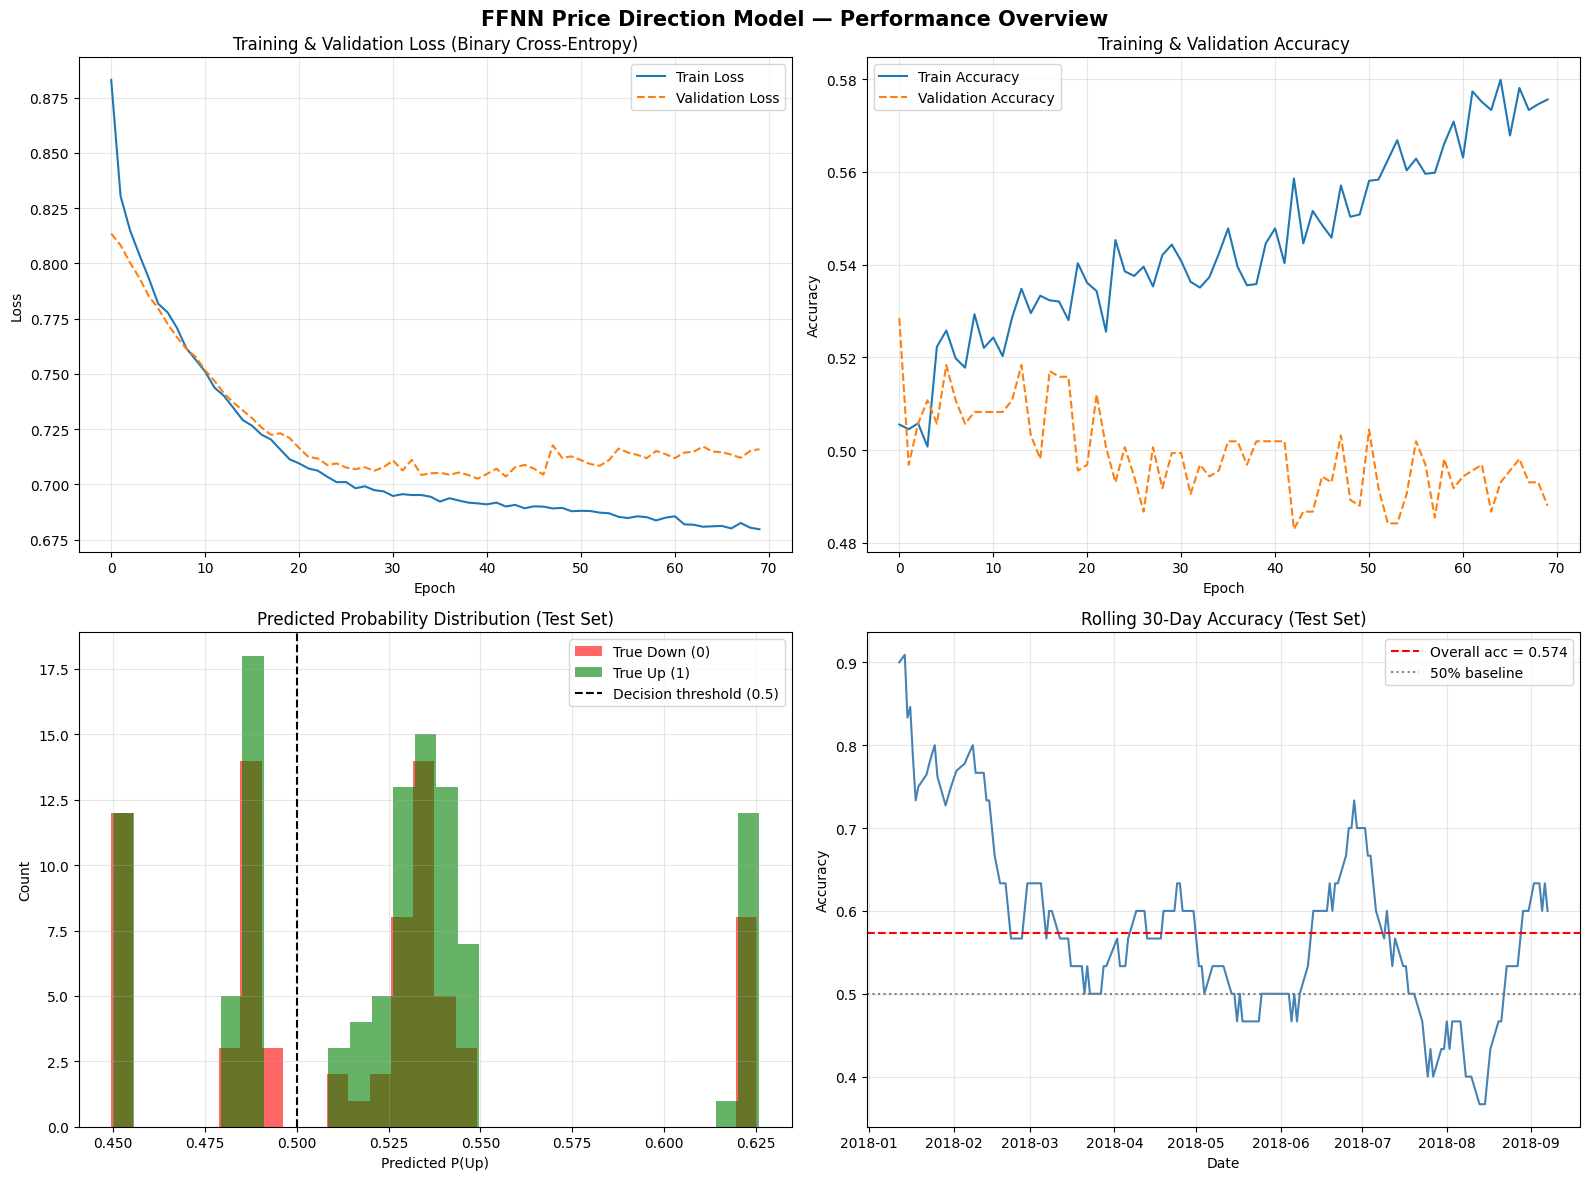

  Performance overview plot saved.


In [ ]:
# =============================================================================
# 15. VISUALISATIONS
# =============================================================================

history = model.history.history

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('FFNN Price Direction Model — Performance Overview', fontsize=15, fontweight='bold')

# Plot 1: Training vs Validation Loss
ax = axes[0, 0]
ax.plot(history['loss'],     label='Train Loss',      linewidth=1.5)
ax.plot(history['val_loss'], label='Validation Loss', linewidth=1.5, linestyle='--')
ax.set_title('Training & Validation Loss (Binary Cross-Entropy)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Training vs Validation Accuracy
ax = axes[0, 1]
ax.plot(history['accuracy'],     label='Train Accuracy',      linewidth=1.5)
ax.plot(history['val_accuracy'], label='Validation Accuracy', linewidth=1.5, linestyle='--')
ax.set_title('Training & Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Predicted Probability Distribution on Test Set
ax = axes[1, 0]
ax.hist(test_proba[y_test == 0], bins=30, alpha=0.6, label='True Down (0)', color='red')
ax.hist(test_proba[y_test == 1], bins=30, alpha=0.6, label='True Up (1)',   color='green')
ax.axvline(0.5, color='black', linestyle='--', label='Decision threshold (0.5)')
ax.set_title('Predicted Probability Distribution (Test Set)')
ax.set_xlabel('Predicted P(Up)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Rolling 30-Day Accuracy on Test Set
ax = axes[1, 1]
test_dates  = pd.Series(dates[test_mask.values])
correct_arr = (test_metrics['y_pred'] == y_test).astype(int)
rolling_acc = pd.Series(correct_arr).rolling(window=30, min_periods=10).mean()
ax.plot(test_dates.values, rolling_acc.values, color='steelblue', linewidth=1.5)
ax.axhline(test_metrics['accuracy'], color='red', linestyle='--',
           label=f'Overall acc = {test_metrics["accuracy"]:.3f}')
ax.axhline(0.5, color='gray', linestyle=':', label='50% baseline')
ax.set_title('Rolling 30-Day Accuracy (Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ffnn_performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Performance overview plot saved.")

## 16. Summary Comparison Table

Final comparison of the FFNN against the majority-class baseline on the test set.

In [ ]:
# =============================================================================
# 16. SUMMARY COMPARISON TABLE
# =============================================================================

print("\n" + "=" * 60)
print("STEP 16: Summary — FFNN vs Baseline (Test Set)")
print("=" * 60)

baseline_acc  = accuracy_score(y_test, baseline_test_pred)
baseline_f1   = f1_score(y_test, baseline_test_pred, average='macro', zero_division=0)

summary = pd.DataFrame({
    'Metric'             : ['Accuracy', 'Precision (Down)', 'Recall (Down)',
                             'Precision (Up)', 'Recall (Up)', 'F1 (macro)', 'ROC-AUC'],
    'Baseline (Majority)': [
        f"{baseline_acc:.4f}",
        f"{precision_score(y_test, baseline_test_pred, pos_label=0, zero_division=0):.4f}",
        f"{recall_score(y_test, baseline_test_pred, pos_label=0, zero_division=0):.4f}",
        f"{precision_score(y_test, baseline_test_pred, pos_label=1, zero_division=0):.4f}",
        f"{recall_score(y_test, baseline_test_pred, pos_label=1, zero_division=0):.4f}",
        f"{baseline_f1:.4f}", 'N/A'
    ],
    'FFNN Model'         : [
        f"{test_metrics['accuracy']:.4f}",
        f"{test_metrics['precision_0']:.4f}",
        f"{test_metrics['recall_0']:.4f}",
        f"{test_metrics['precision_1']:.4f}",
        f"{test_metrics['recall_1']:.4f}",
        f"{test_metrics['f1_macro']:.4f}",
        f"{test_metrics['roc_auc']:.4f}"
    ]
})

print(summary.to_string(index=False))


STEP 16: Summary — FFNN vs Baseline (Test Set)
          Metric Baseline (Majority) FFNN Model
        Accuracy              0.5902     0.5738
Precision (Down)              0.0000     0.4776
   Recall (Down)              0.0000     0.4267
  Precision (Up)              0.5902     0.6293
     Recall (Up)              1.0000     0.6759
      F1 (macro)              0.3711     0.5512
         ROC-AUC                 N/A     0.5677


## 17. Save Model and Scaler

In [ ]:
# =============================================================================
# 17. SAVE MODEL AND SCALER
# =============================================================================

model.save('ffnn_direction_model')

with open('scaler_X_ffnn.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)

print("  Scaler saved to scaler_X_ffnn.pkl")
print("\nPipeline complete.")

  Model saved to ffnn_direction_model.keras
  Scaler saved to scaler_X_ffnn.pkl

Pipeline complete.


# Investment Strategys

# Strategy 1

## Strategy 1: Simple Prediction-Based Trading

This strategy is a straightforward implementation where the model's binary prediction directly dictates the trading action.

- **Entry Condition**: The strategy enters a position (i.e., takes the daily return) if the model predicts an 'Up' movement (i.e., `Prediction` = 1).
- **Exit Condition**: No position is taken (i.e., return is 0) if the model predicts 'Down' (i.e., `Prediction` = 0).
- **Transaction Costs**: A fixed transaction cost of `0.001` is applied only when a position is entered (i.e., when `Prediction` is 1).

In [ ]:
test_df = merged_df[test_mask].copy()
test_df['Prediction'] = test_metrics['y_pred']
test_df['Probability'] = test_proba
test_df['Return'] = test_df['Price'].pct_change().shift(-1)
test_df = test_df.dropna().reset_index(drop=True)

test_df['Strategy1'] = test_df['Prediction'] * test_df['Return']

# Strategy 2

## Strategy 2: Probability Threshold-Based Trading

This strategy employs a higher confidence threshold based on the predicted probability of an 'Up' movement to make trading decisions, aiming for more selective entries.

- **Entry Condition**: The strategy enters a position only if the model's predicted probability of an 'Up' movement (`Probability`) is greater than `0.52`. This acts as a higher confidence filter compared to the simple 0.5 threshold for binary prediction.
- **Exit Condition**: No position is taken if the predicted probability is not above `0.52`.
- **Transaction Costs**: A fixed transaction cost of `0.001` is applied only when the predicted probability of an 'Up' movement is greater than `0.6`, indicating a very high confidence trade. Note that this is a different threshold than the entry threshold, implying that a trade might be entered but not incur a transaction cost if the probability is between 0.52 and 0.6.

In [ ]:
test_df['Strategy2'] = 0

test_df.loc[test_df['Probability'] > 0.52, 'Strategy2'] = test_df['Return']

##  Transaction Cost

In [ ]:
cost = 0.001

test_df['Strategy1'] -= cost * test_df['Prediction']
test_df['Strategy2'] -= cost * (test_df['Probability'] > 0.6)

# FINAL OUTPUT

In [ ]:
test_df['Market'] = test_df['Return']

test_df['Cum_Market'] = (1 + test_df['Market']).cumprod()
test_df['Cum_Strategy1'] = (1 + test_df['Strategy1']).cumprod()
test_df['Cum_Strategy2'] = (1 + test_df['Strategy2']).cumprod()

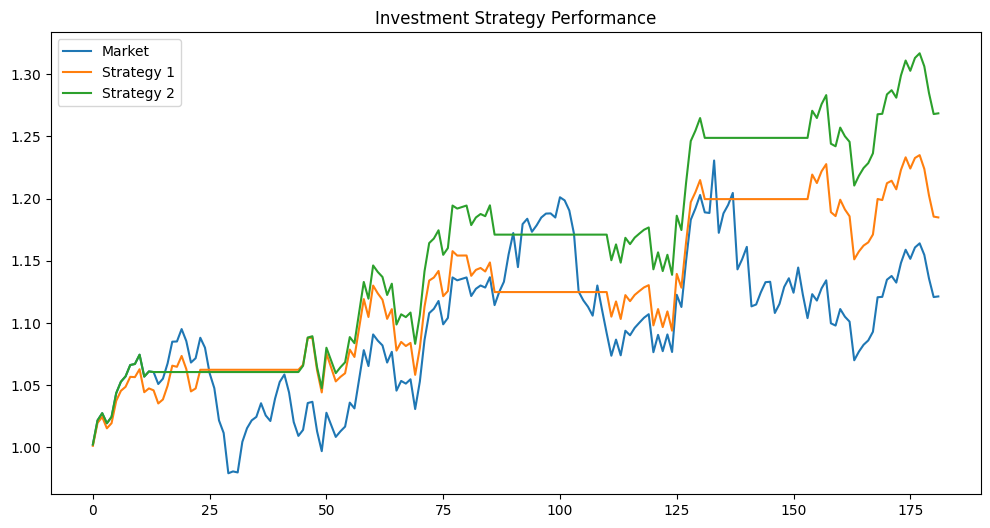

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test_df['Cum_Market'], label='Market')
plt.plot(test_df['Cum_Strategy1'], label='Strategy 1')
plt.plot(test_df['Cum_Strategy2'], label='Strategy 2')

plt.legend()
plt.title("Investment Strategy Performance")

plt.show()

## Final Metrics

In [ ]:
def perf(x):
    return (1+x).prod()-1, x.mean()/x.std()*np.sqrt(252)

print("Strategy1:", perf(test_df['Strategy1']))
print("Strategy2:", perf(test_df['Strategy2']))
print("Market:", perf(test_df['Market']))

Strategy1: (np.float64(0.18484295047998178), np.float64(1.4167447466658158))
Strategy2: (np.float64(0.26847553621322073), np.float64(1.9924594878144886))
Market: (np.float64(0.12134794156706308), np.float64(0.7685230467652862))


## Final Metrics

The `perf` function calculates two key performance indicators for each strategy and the market (buy-and-hold):

1.  **Cumulative Return:** This represents the total percentage gain or loss over the entire period. It's calculated as `(1 + daily_returns).prod() - 1`.
2.  **Annualized Sharpe Ratio:** This measures the risk-adjusted return of an investment. A higher Sharpe ratio indicates better risk-adjusted performance. It's calculated as `(mean_daily_return / std_dev_daily_return) * sqrt(252)` (assuming 252 trading days in a year).

Based on the output:

-   **Strategy 1:**
    -   **Cumulative Return:** 18.48% (0.1848)
    -   **Annualized Sharpe Ratio:** 1.4167

-   **Strategy 2:**
    -   **Cumulative Return:** 26.85% (0.2685)
    -   **Annualized Sharpe Ratio:** 1.9925

-   **Market (Buy-and-Hold):**
    -   **Cumulative Return:** 12.13% (0.1213)
    -   **Annualized Sharpe Ratio:** 0.7685

**Interpretation:**

*   **Strategy 2 clearly outperforms Strategy 1 and the Market.** It delivers the highest cumulative return (26.85%) and significantly better risk-adjusted returns (Sharpe Ratio of 1.9925). This suggests that using a higher confidence threshold for trading decisions leads to more profitable and less volatile outcomes.
*   **Strategy 1 also outperforms the Market.** With a cumulative return of 18.48% and a Sharpe Ratio of 1.4167, it demonstrates a better performance than simply holding the asset, despite its simpler decision rule.
*   The **Market** (buy-and-hold) serves as a baseline, showing a positive but lower return and risk-adjusted return compared to both active strategies. This indicates that the developed FFNN model, especially when combined with Strategy 2's thresholding, has successfully identified profitable trading opportunities in the WTI Crude Oil market.